# 06 — Platform KPIs (in-notebook Executive Overview)

Renders the same KPI set as the Power BI "Executive Overview" page (`ARCHITECTURE.md §13`) directly in the notebook with matplotlib — for anyone reviewing this project without Power BI access. Metric definitions follow `docs/semantic-dictionary.md` (Revenue = completed orders only, excluding canceled — see `ARCHITECTURE.md §11`).

Run `make seed` from the repo root before running this notebook. Self-contained — does not import the other notebooks.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OLIST_DIR = ROOT / "data" / "raw" / "olist"
SYNTH_DIR = ROOT / "data" / "synthetic"

# Olist needs an interactive Kaggle login (`make download-olist`) and may not be present —
# the platform degrades gracefully without it (ADR-009): when absent, this notebook computes
# the same KPI set from the always-available synthetic CRM + Finance sources instead
# (settled payments standing in for completed orders).
HAS_OLIST = all((OLIST_DIR / f).exists() for f in
                 ["olist_orders_dataset.csv", "olist_order_payments_dataset.csv", "olist_customers_dataset.csv"])

required = [SYNTH_DIR / "crm" / "crm_customers.csv", SYNTH_DIR / "finance" / "customer_payments.csv"]
missing = [str(p) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError("Missing: " + ", ".join(missing) + " — run `make seed` first.")

if HAS_OLIST:
    orders = pd.read_csv(OLIST_DIR / "olist_orders_dataset.csv", parse_dates=["order_purchase_timestamp"])
    payments = pd.read_csv(OLIST_DIR / "olist_order_payments_dataset.csv")
    customers = pd.read_csv(OLIST_DIR / "olist_customers_dataset.csv")
    print(f"[Olist] orders: {len(orders):,} | payments: {len(payments):,} | customers: {len(customers):,}")
else:
    crm = pd.read_csv(SYNTH_DIR / "crm" / "crm_customers.csv")
    fin_payments = pd.read_csv(SYNTH_DIR / "finance" / "customer_payments.csv", parse_dates=["settled_at"])
    print(f"[Synthetic fallback — Olist not downloaded] crm: {len(crm):,} | payments: {len(fin_payments):,}")

[Synthetic fallback — Olist not downloaded] crm: 10,500 | payments: 10,000


## Compute headline KPIs

`Revenue`, `Orders`, `Customers`, `AOV` follow the canonical definitions in `docs/semantic-dictionary.md`: completed orders only (`order_status` not in `canceled`/`unavailable`).

In [2]:
if HAS_OLIST:
    EXCLUDED_STATUSES = {"canceled", "unavailable"}
    completed = orders[~orders["order_status"].isin(EXCLUDED_STATUSES)]

    order_revenue = (
        payments.groupby("order_id")["payment_value"].sum()
        .reindex(completed["order_id"]).fillna(0)
    )

    revenue = order_revenue.sum()
    n_orders = len(completed)
    n_customers = customers["customer_unique_id"].nunique()
    aov = revenue / n_orders if n_orders else 0
    repeat_customers = (
        orders.merge(customers[["customer_id", "customer_unique_id"]], on="customer_id")
        .groupby("customer_unique_id")["order_id"].nunique()
    )
    repeat_rate = (repeat_customers > 1).mean()
else:
    # Synthetic fallback: settled payments stand in for "completed orders" (ADR-009).
    settled = fin_payments[fin_payments["status"] == "settled"]
    revenue = settled["net_amount"].sum()
    n_orders = len(settled)  # 1 payment ~= 1 order-equivalent in this proxy
    n_customers = crm["crm_customer_id"].nunique()
    aov = revenue / n_orders if n_orders else 0
    payments_per_customer = settled.groupby("customer_id")["payment_id"].nunique()
    repeat_rate = (payments_per_customer > 1).mean() if len(payments_per_customer) else 0.0

kpis = {
    "Revenue": f"R$ {revenue:,.0f}",
    "Orders": f"{n_orders:,}",
    "Customers": f"{n_customers:,}",
    "AOV": f"R$ {aov:,.2f}",
    "Repeat Rate": f"{repeat_rate:.1%}",
}
if not HAS_OLIST:
    print("(Olist not available — Revenue/Orders/AOV computed from synthetic settled payments, not real order data.)")
kpis

(Olist not available — Revenue/Orders/AOV computed from synthetic settled payments, not real order data.)


{'Revenue': 'R$ 15,666,556',
 'Orders': '9,324',
 'Customers': '10,500',
 'AOV': 'R$ 1,680.24',
 'Repeat Rate': '38.3%'}

## KPI cards

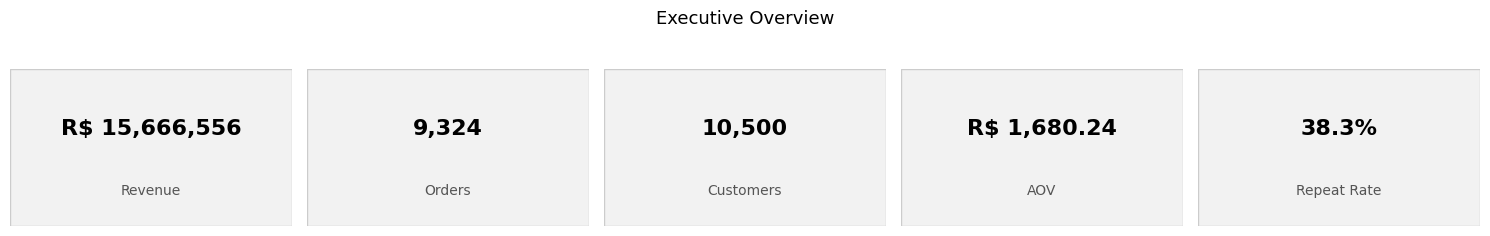

In [3]:
fig, axes = plt.subplots(1, len(kpis), figsize=(3 * len(kpis), 2.2))
for ax, (label, value) in zip(axes, kpis.items()):
    ax.axis("off")
    ax.add_patch(plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes,
                                facecolor="#F2F2F2", edgecolor="#CCCCCC"))
    ax.text(0.5, 0.62, value, ha="center", va="center", fontsize=16, fontweight="bold")
    ax.text(0.5, 0.22, label, ha="center", va="center", fontsize=10, color="#555555")
plt.suptitle("Executive Overview", fontsize=13, y=1.05)
plt.tight_layout()
plt.show()

## Revenue trend and top states

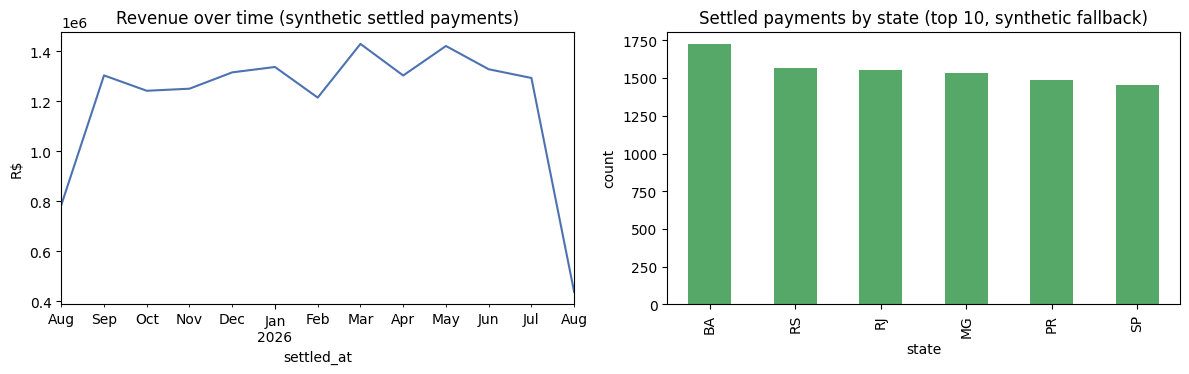

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if HAS_OLIST:
    completed_with_revenue = completed.assign(revenue=order_revenue.values)
    monthly_revenue = (
        completed_with_revenue.set_index("order_purchase_timestamp")["revenue"]
        .resample("MS").sum()
    )
    orders_by_state = (
        orders.merge(customers[["customer_id", "customer_state"]], on="customer_id")
        ["customer_state"].value_counts().head(10)
    )
    axes[1].set_title("Orders by state (top 10)")
else:
    monthly_revenue = settled.set_index("settled_at")["net_amount"].resample("MS").sum()
    orders_by_state = (
        settled.merge(crm[["crm_customer_id", "state"]], left_on="customer_id", right_on="crm_customer_id")
        ["state"].value_counts().head(10)
    )
    axes[1].set_title("Settled payments by state (top 10, synthetic fallback)")

monthly_revenue.plot(ax=axes[0], color="#4C72B0")
axes[0].set_title("Revenue over time" + ("" if HAS_OLIST else " (synthetic settled payments)"))
axes[0].set_ylabel("R$")

orders_by_state.plot.bar(ax=axes[1], color="#55A868")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

## Data Quality Score (compact)

A one-line summary of notebook 01's fuller breakdown, included here so the Executive Overview always ships with a trust signal next to the business numbers — exactly the pairing `ARCHITECTURE.md §7` argues for ("the platform reports its own trustworthiness, not just business metrics").

In [5]:
if HAS_OLIST:
    key_columns = {
        "orders.order_id": orders["order_id"],
        "orders.customer_id": orders["customer_id"],
        "customers.customer_unique_id": customers["customer_unique_id"],
    }
    completeness_scores = [1 - s.isna().mean() for s in key_columns.values()]
    uniqueness_score = 1 - orders["order_id"].duplicated().mean()
else:
    key_columns = {
        "crm.email": crm["email"],
        "crm.phone": crm["phone"],
        "crm.document_hash": crm["document_hash"],
    }
    completeness_scores = [1 - s.isna().mean() for s in key_columns.values()]
    uniqueness_score = 1 - crm["document_hash"].dropna().duplicated().mean()

dq_score = (sum(completeness_scores) / len(completeness_scores) + uniqueness_score) / 2

print(f"Data Quality Score (compact): {dq_score:.1%}")
print("See 01_data_quality_overview.ipynb for the full breakdown by dimension.")

Data Quality Score (compact): 97.2%
See 01_data_quality_overview.ipynb for the full breakdown by dimension.


## Maps to the real pipeline

- Power BI "Executive Overview" page (`powerbi/`) — the production version of this page, sourced from the semantic layer (Snowflake Semantic Views / Unity Catalog Metric Views), never from raw tables directly (ADR-005) — this notebook computes straight from Olist CSVs only because it has no warehouse to query locally.
- `docs/semantic-dictionary.md` — the canonical Revenue/AOV/Repeat Rate definitions this notebook implements a local copy of.
- `01_data_quality_overview.ipynb`, `03_churn_model_explainability.ipynb`, `04_customer_segmentation.ipynb` — the fuller versions of the DQ score and (not shown here, since it needs the synthetic CRM join) churn/segment KPIs.